# Solve surface volatiles according to outgassing+chemistry

In [1]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 12})
mpl.rcParams['axes.formatter.useoffset'] = False

from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from cmcrameri import cm

from calliope.solve import *
from calliope.structure import calculate_mantle_mass
from calliope.constants import R_earth, const_G, M_earth

from proteus.utils.plot import latexify

In [2]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
# %matplotlib widget

### Set up initial options dict

In [77]:
OPTIONS = {}

OPTIONS['Phi_global'] = 0.40
OPTIONS['T_magma'] = 1850.0

OPTIONS['radius'] = R_earth * 1.273
OPTIONS['mass']   = M_earth * 2.14
OPTIONS['gravity'] = const_G * OPTIONS['mass'] / (OPTIONS['radius']**2)
OPTIONS['hydrogen_earth_oceans'] = 405.0
OPTIONS['CH_ratio'] = 1.0
OPTIONS['fO2_shift_IW'] = -3.0
OPTIONS['nitrogen_ppmw'] = 0.0
OPTIONS['sulfur_ppmw'] = 3000.0
OPTIONS['planet_coresize'] = 0.55

solvevol_vols = ['H2O', 'CO2', 'N2', 'H2', 'CO', 'CH4', 'S2', 'SO2', 'H2S', 'NH3']
for v in solvevol_vols:
    OPTIONS[v+"_included"] = 0
    OPTIONS[v+"_initial_bar"] = 0.0

OPTIONS["H2O_included"] = 1
OPTIONS["CO2_included"] = 1
OPTIONS["N2_included"]  = 1
OPTIONS["S2_included"]  = 1

OPTIONS["H2_included"]  = 1
OPTIONS["CO_included"]  = 1
OPTIONS["CH4_included"] = 1
OPTIONS["SO2_included"] = 1
OPTIONS["H2S_included"] = 1
OPTIONS["NH3_included"] = 0
OPTIONS["O2_included"] = 1

print("Gravity = %.3f m.s-2" % OPTIONS["gravity"])

Gravity = 13.114 m.s-2


### Calculate total amount of each element in the system

In [78]:
OPTIONS["M_mantle"] = calculate_mantle_mass(OPTIONS["radius"], OPTIONS["mass"], OPTIONS["planet_coresize"])
BACKUP_options = deepcopy(OPTIONS)

In [79]:
solvevol_target = get_target_from_params(OPTIONS)
print(solvevol_target)

{'H': 6.277499999999999e+22, 'C': 6.277499999999999e+22, 'N': 0.0, 'S': 2.6328397592834106e+22}


In [80]:
print(solvevol_target['H']/OPTIONS["M_mantle"] * 1e6)
print(solvevol_target['S']/solvevol_target['H'])

7152.922973605391
0.41940896205231554


### Parameter sweep demo

In [107]:
plt.close("all")

# parameters
x_key = "fO2_shift_IW"
x_arr = np.linspace(-5, 5, 25)

y_key = "sulfur_ppmw"
y_arr = np.linspace(0, 120_000, 25)

# out keys
z_out = {}
for k in [v+"_vmr" for v in solvevol_vols]:
    z_out[k] = []
for k in [v+"_bar" for v in solvevol_vols]:
    z_out[k] = []
z_out["atm_kg_per_mol"] = []

# run model
x_plt = []
y_plt = []
p_guess = None
for i in range(len(x_arr)):
    print("%02d/%02d (%d)"%(i+1,len(x_arr), len(y_arr)))
    for j in range(len(y_arr)):
        print("  %d"%(j+1), end='')

        x = x_arr[i]
        y = y_arr[j]

        OPTIONS = deepcopy(BACKUP_options)
        OPTIONS[x_key] = x
        OPTIONS[y_key] = y

        solvevol_target = get_target_from_params(OPTIONS)
        p_d = equilibrium_atmosphere(solvevol_target, OPTIONS, opt_solver=False,
                                        p_guess=p_guess,
                                        rtol=1e-9, xtol=1e-8, atol=1e2, nsolve=600)
        for k in z_out.keys():
            z_out[k].append(p_d[k])

        p_guess = {}
        for g in ("H2O","CO2","N2","S2"):
            p_guess[g] = p_d[f"{g}_bar"]

        # plot x: fO2
        x_plt.append(x)

        # plot y: S/H ratio
        yy = solvevol_target['S']/solvevol_target['H']
        y_plt.append(yy)
    print("")

print("Done")

01/25 (25)
  1

/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']

  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
02/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
03/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
04/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
05/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
06/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
07/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
08/25 (25)
  1  2  3  4  5  6  7  8  9  10  11

/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']

  12  13  14  15  16  17  18  19  20  21  22  23  24  25
09/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
10/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
11/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20

...

/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']

  21  22  23  24  25
18/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
19/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
20/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
21/25 (25)
  1

/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']

  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
22/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
23/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
24/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
25/25 (25)
  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
Done


/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:103: RuntimeWarning: invalid value encountered in scalar power
  p_d['SO2']  = (gamma*pin['S2']*p_d['O2']**2)**0.5
/home2/p321409/Projects/CALLIOPE/src/calliope/solve.py:109: RuntimeWarning: invalid value encountered in scalar power
  p_d['H2S']  = (gamma*pin['S2']*p_d['H2']**2)**0.5


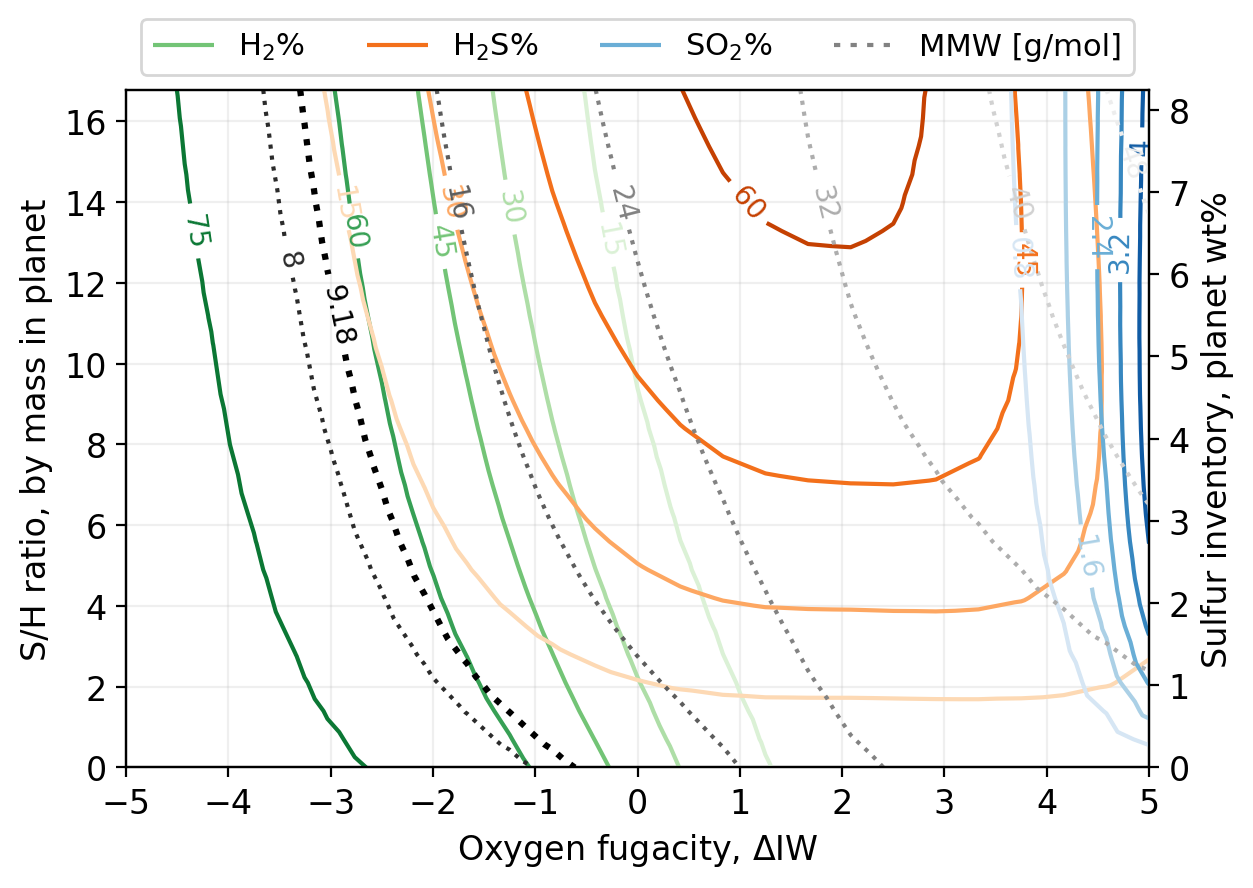

In [117]:
# plot data
figs = 1.1
fig,ax = plt.subplots(1,1, figsize=(6*figs,4    *figs))

norm = 'linear'
vmin = 0.0
vmax = None
levs = 5
lw = 1.5

pairs = [
    ("H2_vmr","Greens",'solid'),
    # ("CO_vmr","Purples",'dashed'),
    ("H2S_vmr","Oranges",'solid'),
    ("SO2_vmr","Blues",'solid'),
    ("atm_kg_per_mol", "Greys_r",'dotted')]
artists, labels = [], []
for p in pairs:

    plt_mmw = False

    scale = 1.0
    if "vmr" in p[0]:
        scale = 1e2
        label = latexify(p[0].split("_")[0]) + "%"
    elif "kg_per_mol" in p[0]:
        scale = 1e3
        label = "MMW [g/mol]"
        plt_mmw = True

    z_plt = np.array(z_out[p[0]]) * scale
    z_plt[z_plt<vmin] = 0

    cmap = deepcopy(plt.get_cmap(p[1]))

    cs = ax.tricontour(x_plt, y_plt, z_plt,
                        norm=norm, vmin=vmin, vmax=vmax, cmap=cmap,
                        levels=levs, linestyles=p[2], linewidths=lw, zorder=4)
    ax.clabel(cs,cs.levels, fmt="%g", fontsize=10)

    a, _ = cs.legend_elements()
    artists.append(a[3])
    labels.append(label)

    if plt_mmw:
        cs = ax.tricontour(x_plt, y_plt, z_plt,
                        cmap=cmap,
                        levels=[9.18,], linestyles=p[2], linewidths=lw*1.5, zorder=8)
        ax.clabel(cs,cs.levels, fmt="%g", fontsize=10)


ax.grid(zorder=-2,alpha=0.2)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_xlabel(r"Oxygen fugacity, $\Delta$IW")

ax.set_ylabel("S/H ratio, by mass in planet")
ymin = np.amin(y_plt)
ymax = np.amax(y_plt)
ax.set_ylim(ymin, ymax)

axr = ax.twinx()
ymin *= solvevol_target['H'] / OPTIONS['mass'] * 100
ymax *= solvevol_target['H'] / OPTIONS['mass'] * 100
axr.set_ylim(bottom=ymin, top=ymax)
axr.set_ylabel("Sulfur inventory, planet wt%")

ax.legend(artists, labels, loc='lower center', bbox_to_anchor=(0.5,1), ncols=5, fontsize=11)
plt.show()
fig.savefig("nogit_contour.pdf",bbox_inches='tight',dpi=450)